In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv('Symptom2Disease.csv')

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Encode categorical variables (Target)
label_enc = LabelEncoder()
y = label_enc.fit_transform(data['Disease'])

# Extract the symptom text column (Features)
# Note: Check if your column is named 'text' or 'Symptom'. 
# Standard Kaggle version uses 'text'.
X_text = data['text'] 

# Convert text descriptions into numerical features instead of StandardScaler
tfidf = TfidfVectorizer(max_features=1500)
X_scaled = tfidf.fit_transform(X_text).toarray()

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Step 5: Train Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [17]:
# Step 6: Evaluate Model
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9416666666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        11
           3       1.00      1.00      1.00         7
           4       0.80      0.67      0.73        12
           5       1.00      1.00      1.00        12
           6       0.89      0.67      0.76        12
           7       1.00      1.00      1.00         7
           8       1.00      1.00      1.00        13
           9       1.00      1.00      1.00        10
          10       1.00      1.00      1.00        11
          11       1.00      1.00      1.00        11
          12       1.00      1.00      1.00        11
          13       1.00      1.00      1.00        10
          14       1.00      1.00      1.00        11
          15       0.83      0.83      0.83         6
          16       0.82      1.00      0.90         

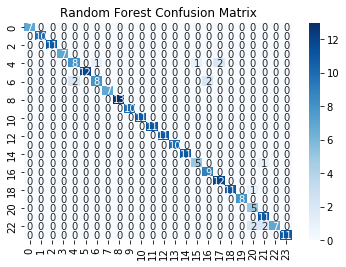

In [18]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.show()

In [28]:
new_patient_symptoms = [
                        "I have a high fever, severe headache, and a runny nose.",
                        "My joints are aching severely and I have red rashes on my skin.",
                        "I am experiencing constant stomach pain, nausea, and vomiting."
                        ]

# 2. Transform the text using the ALREADY FITTED tfidf object

new_patient_vectorized = tfidf.transform(new_patient_symptoms).toarray()

# 3. Pass the 1500-feature vector to the model
prediction = model.predict(new_patient_vectorized)

# 4. Decode the number back to the disease string name
disease_name = label_enc.inverse_transform(prediction)
print("Predicted Disease:", disease_name[1])

Predicted Disease: 15
